In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../data/neurosense_cleaned"".csv")


print("Dataset shape:", df.shape)
print(df.head())

(37575, 361)


,eeg_feature_1,eeg_feature_2,eeg_feature_3,eeg_feature_4,eeg_feature_5,eeg_feature_6,eeg_feature_7,eeg_feature_8,eeg_feature_9,eeg_feature_10,...,eye_range,eeg_stability,eye_stability,phys_activity,label,emotion,subject,session,trial,sample
0,26.791522,24.062115,21.927618,19.697461,18.626858,26.781416,24.090212,21.992052,19.634864,18.446852,...,6148.7,6.623193,0.289054,359.072631,1,Sad,10,1,1,0
1,26.791101,24.061706,21.928215,19.697127,18.626882,26.780972,24.089481,21.992834,19.634719,18.447054,...,6148.7,6.622985,0.289050,359.068374,1,Sad,10,1,1,1
2,26.791650,24.062570,21.929218,19.696753,18.626936,26.783116,24.090431,21.994368,19.634771,18.447366,...,6148.7,6.622051,0.289049,359.067974,1,Sad,10,1,1,2
3,26.793695,24.063827,21.931248,19.696395,18.626931,26.787306,24.092226,21.997363,19.634678,18.447735,...,6148.7,6.620988,0.289037,359.054303,1,Sad,10,1,1,3
4,26.794138,24.064473,21.933663,19.696645,18.627109,26.790289,24.093457,22.000899,19.635314,18.448518,...,6148.7,6.619975,0.289018,359.032246,1,Sad,10,1,1,4


In [2]:
# 3. Mapping nga 4 klasa në 3 klasa

def map_emotion(label):
    if label == 0:
        return 0   # Neutral
    elif label in [1, 2]:
        return 1   # Negative
    elif label == 3:
        return 2   # Positive

df["label_3class"] = df["label"].apply(map_emotion)

print(df["label"].value_counts())
print(df["label_3class"].value_counts())

label
0    9750
2    9735
1    9525
3    8565
Name: count, dtype: int64
label_3class
1    19260
0     9750
2     8565
Name: count, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10128\581957294.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["label_3class"] = df["label"].apply(map_emotion)


In [3]:
# 4. Ndarja e features dhe target

X = df.drop(
    columns=["label", "label_3class", "subject", "session", "trial", "sample"],
    errors="ignore"
)

y = df["label_3class"]

X = X.select_dtypes(include=["number"])

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (37575, 355)
y shape: (37575,)
label_3class
1    19260
0     9750
2     8565
Name: count, dtype: int64


In [4]:
# 5. Train/Test Split me GroupShuffleSplit sipas subject

groups = df["subject"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain label distribution:")
print(y_train.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())

Train shape: (30060, 355)
Test shape: (7515, 355)

Train label distribution:
label_3class
1    15408
0     7800
2     6852
Name: count, dtype: int64

Test label distribution:
label_3class
1    3852
0    1950
2    1713
Name: count, dtype: int64


In [5]:
# 6. Random Forest bazik

rf_basic = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_basic.fit(X_train, y_train)

y_pred_rf_basic = rf_basic.predict(X_test)

In [6]:
# 7. Vlerësimi i Random Forest bazik

rf_basic_results = {
    "Model": "Random Forest Basic 3-Class",
    "Accuracy": accuracy_score(y_test, y_pred_rf_basic),
    "Precision": precision_score(y_test, y_pred_rf_basic, average="weighted"),
    "Recall": recall_score(y_test, y_pred_rf_basic, average="weighted"),
    "F1-score": f1_score(y_test, y_pred_rf_basic, average="weighted")
}

print("Random Forest Basic Results")
for key, value in rf_basic_results.items():
    print(key, ":", value)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf_basic,
    target_names=["Neutral", "Negative", "Positive"]
))

Random Forest Basic Results
Model : Random Forest Basic 3-Class
Accuracy : 0.5500998003992016
Precision : 0.5508826807923288
Recall : 0.5500998003992016
F1-score : 0.4739371940263559

Classification Report:
              precision    recall  f1-score   support

     Neutral       0.53      0.27      0.36      1950
    Negative       0.55      0.90      0.69      3852
    Positive       0.57      0.07      0.13      1713

    accuracy                           0.55      7515
   macro avg       0.55      0.42      0.39      7515
weighted avg       0.55      0.55      0.47      7515



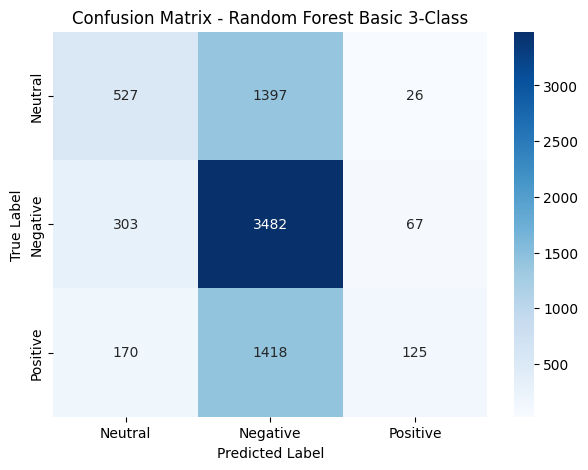

In [7]:
# 8. Confusion Matrix për Random Forest bazik

cm_basic = confusion_matrix(y_test, y_pred_rf_basic)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_basic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Neutral", "Negative", "Positive"],
    yticklabels=["Neutral", "Negative", "Positive"]
)

plt.title("Confusion Matrix - Random Forest Basic 3-Class")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [9]:
# 9. Feature Importance

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_basic.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(20)

,Feature,Importance
310,eye_feature_1,0.016319
314,eye_feature_5,0.015517
315,eye_feature_6,0.014928
317,eye_feature_8,0.012596
318,eye_feature_9,0.012571
321,eye_feature_12,0.010238
311,eye_feature_2,0.009851
335,eye_feature_26,0.009658
349,eeg_eye_ratio,0.008665
347,max_eye,0.008331


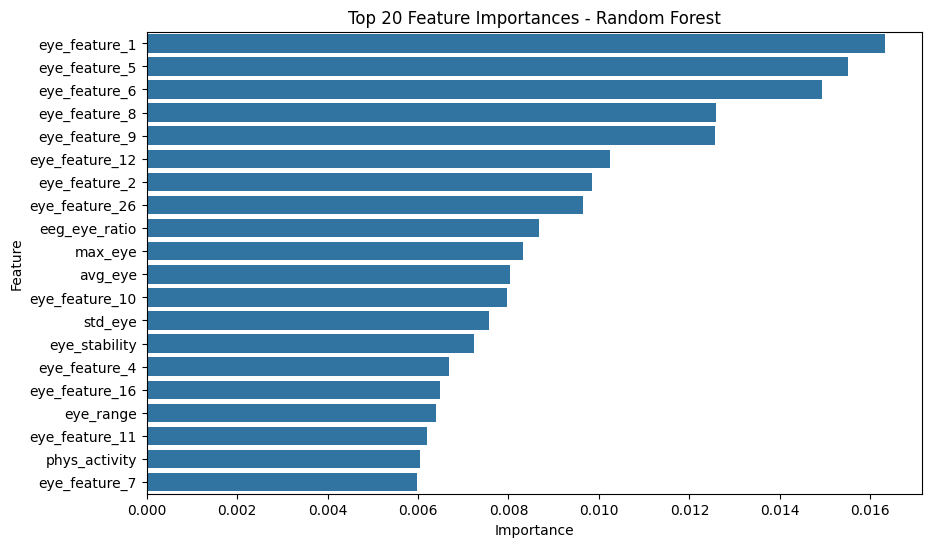

In [10]:
# 10. Vizualizimi i Top 20 Feature Importance

top_20_features = feature_importance_df.head(20)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_20_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [11]:
# 11. Hyperparameter Tuning për Random Forest

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "class_weight": [None, "balanced"]
}

grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2
)

grid_search_rf.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search_rf.best_params_)

print("Best CV Score:")
print(grid_search_rf.best_score_)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best Parameters:
{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Score:
0.45334445452430217


In [12]:
# 12. Vlerësimi final i Random Forest pas tuning

best_rf_model = grid_search_rf.best_estimator_

y_pred_best_rf = best_rf_model.predict(X_test)

rf_final_results = {
    "Model": "Random Forest + GridSearchCV 3-Class",
    "Accuracy": accuracy_score(y_test, y_pred_best_rf),
    "Precision": precision_score(y_test, y_pred_best_rf, average="weighted"),
    "Recall": recall_score(y_test, y_pred_best_rf, average="weighted"),
    "F1-score": f1_score(y_test, y_pred_best_rf, average="weighted"),
    "Best Parameters": grid_search_rf.best_params_
}

print("Final Random Forest Results")
for key, value in rf_final_results.items():
    print(key, ":", value)

print("\nFinal Classification Report:")
print(classification_report(
    y_test,
    y_pred_best_rf,
    target_names=["Neutral", "Negative", "Positive"]
))

Final Random Forest Results
Model : Random Forest + GridSearchCV 3-Class
Accuracy : 0.5691284098469728
Precision : 0.5706855698723245
Recall : 0.5691284098469728
F1-score : 0.5544292452333089
Best Parameters : {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Final Classification Report:
              precision    recall  f1-score   support

     Neutral       0.46      0.58      0.51      1950
    Negative       0.63      0.71      0.67      3852
    Positive       0.56      0.25      0.35      1713

    accuracy                           0.57      7515
   macro avg       0.55      0.51      0.51      7515
weighted avg       0.57      0.57      0.55      7515



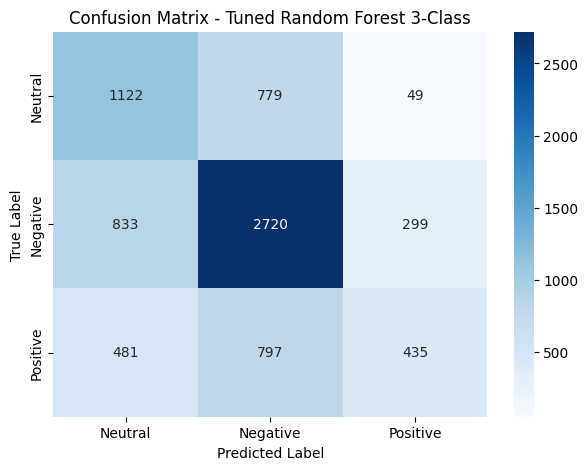

,Model,Accuracy,Precision,Recall,F1-score,Best Parameters
0,Random Forest Basic 3-Class,0.550100,0.550883,0.550100,0.473937,NaN
1,Random Forest + GridSearchCV 3-Class,0.569128,0.570686,0.569128,0.554429,"{'class_weight': 'balanced', 'max_depth': 10, ..."


In [13]:
# 13. Confusion Matrix final

cm_final = confusion_matrix(y_test, y_pred_best_rf)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Neutral", "Negative", "Positive"],
    yticklabels=["Neutral", "Negative", "Positive"]
)

plt.title("Confusion Matrix - Tuned Random Forest 3-Class")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
# 14. Krahasimi Basic vs Tuned

rf_comparison_df = pd.DataFrame([
    rf_basic_results,
    rf_final_results
])

rf_comparison_df

In [14]:
# 15. Ruajtja e rezultateve për comparison.ipynb

rf_results_df = pd.DataFrame([rf_final_results])

rf_results_df.to_csv("../results/tables/random_forest_results.csv", index=False)
rf_comparison_df.to_csv("../results/tables/random_forest_comparison_results.csv", index=False)

rf_results_df

,Model,Accuracy,Precision,Recall,F1-score,Best Parameters
0,Random Forest + GridSearchCV 3-Class,0.569128,0.570686,0.569128,0.554429,"{'class_weight': 'balanced', 'max_depth': 10, ..."
